In [1]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(Param_symbol)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [13]:
RUN_ID = 'first'
SELECTION = 'accuracy'
DT = 1
Q0 = 17921.57581 
ITS = int(15e3)

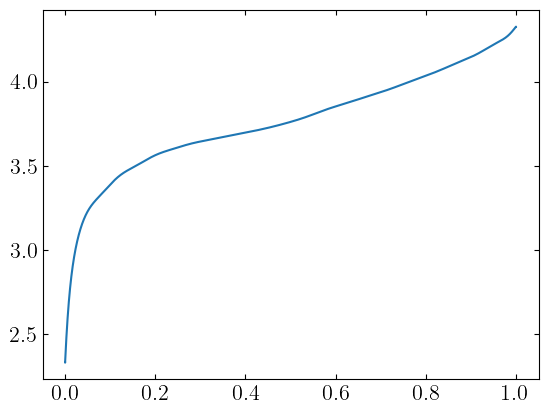

In [11]:
soc = np.linspace(-0.01,1.01,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
plt.plot(soc, Ue)

In [10]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

In [ ]:
import_reload()
model_Ue = Param_symbol.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
Param_symbol.print_models(df_model_Ue)
Param_symbol.print_best_model(model_Ue)
Param_symbol.pareto_plot(model_Ue)
Param_symbol.parity_plot_Ue(model_Ue, X_train, Y_train, colors=colors, data_set='train')

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id R0_first...
Settings: iterations=15000, populations=30, selection=accuracy


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


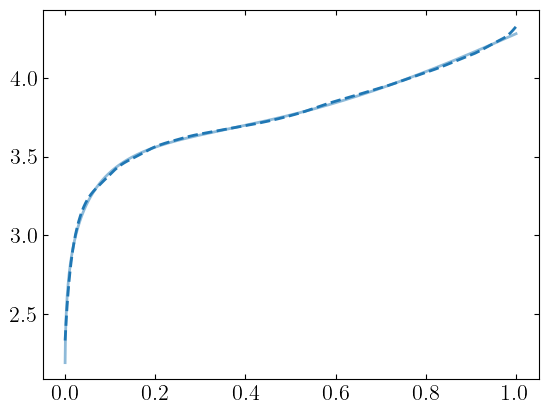

In [ ]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [ ]:
SAVE  = True
if SAVE:
    Param_symbol.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}')
    Param_symbol.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}')
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')